# Practical Task 5 - Data Visualization Portfolio

## 2. Import Libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Setting the visual theme for all plots
sns.set_theme(style="whitegrid")
plt.style.use('ggplot')

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Data

We load the `data.csv` file which contains the COVID-19 statistics.

In [16]:
# Load the dataset from CSV
df = pd.read_csv('data.csv')

# Display first 5 rows to verify the data
display(df.head())

,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,NaN,NaN
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,NaN,8632.0
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,17762.0
3,Diamond-Princess,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,712,699.0,13.0,NaN
4,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,NaN,NaN


## 4. Data Preprocessing

In [17]:
# Convert 'day' column to datetime
df['day'] = pd.to_datetime(df['day'])

# Handle missing values by filling with 0 (assuming no data means zero count in this context)
df = df.fillna(0)

# Ensure numeric columns are properly formatted
numeric_cols = ['Cases', 'Recovered', 'Deaths', 'Tests', 'population']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

print("Data preprocessing complete.")
df.info()

Data preprocessing complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   country     238 non-null    object        
 1   continent   238 non-null    object        
 2   population  238 non-null    float64       
 3   day         238 non-null    datetime64[ns]
 4   time        238 non-null    object        
 5   Cases       238 non-null    int64         
 6   Recovered   238 non-null    float64       
 7   Deaths      238 non-null    float64       
 8   Tests       238 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 16.9+ KB


## 5. Line Plot (Time Series)

Visualizing the trend of COVID-19 cases over time for specific countries.

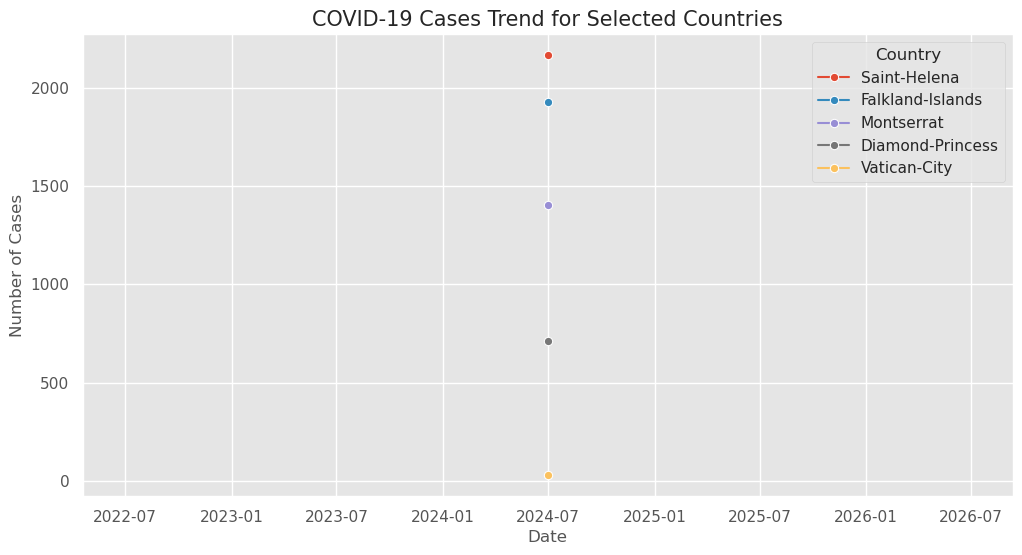

In [18]:
plt.figure(figsize=(12, 6))
# Selecting a few countries for comparison
selected_countries = df['country'].unique()[:5]
df_filtered = df[df['country'].isin(selected_countries)]

sns.lineplot(data=df_filtered, x='day', y='Cases', hue='country', marker='o')
plt.title('COVID-19 Cases Trend for Selected Countries', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend(title='Country')
plt.show()

## 6. Bar Chart

/tmp/ipykernel_1219323/1529567383.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_cases, x='Cases', y='country', palette='viridis')


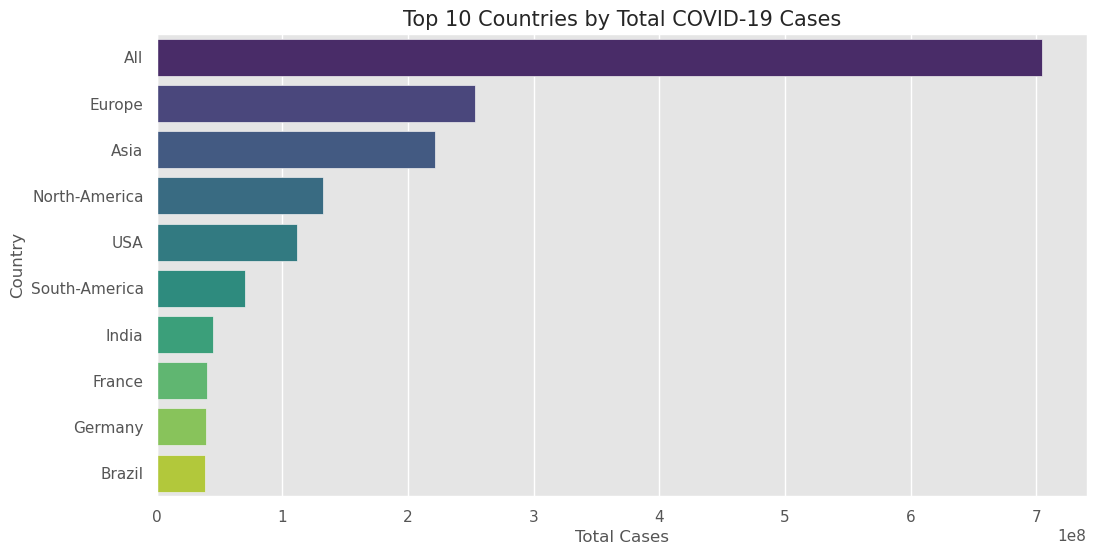

In [19]:
top_10_cases = df.sort_values(by='Cases', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_cases, x='Cases', y='country', palette='viridis')
plt.title('Top 10 Countries by Total COVID-19 Cases', fontsize=15)
plt.xlabel('Total Cases')
plt.ylabel('Country')
plt.show()

## 7. Histogram

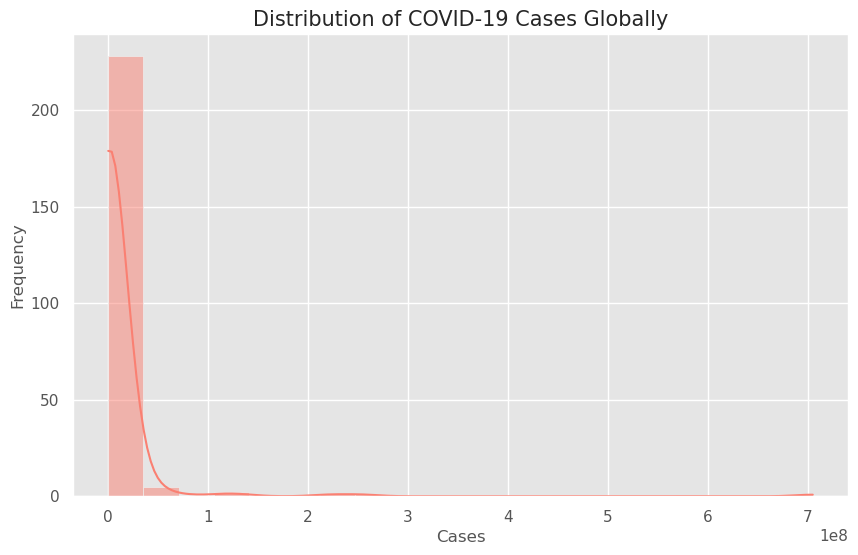

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Cases'], bins=20, kde=True, color='salmon')
plt.title('Distribution of COVID-19 Cases Globally', fontsize=15)
plt.xlabel('Cases')
plt.ylabel('Frequency')
plt.show()

## 8. Scatter Plot

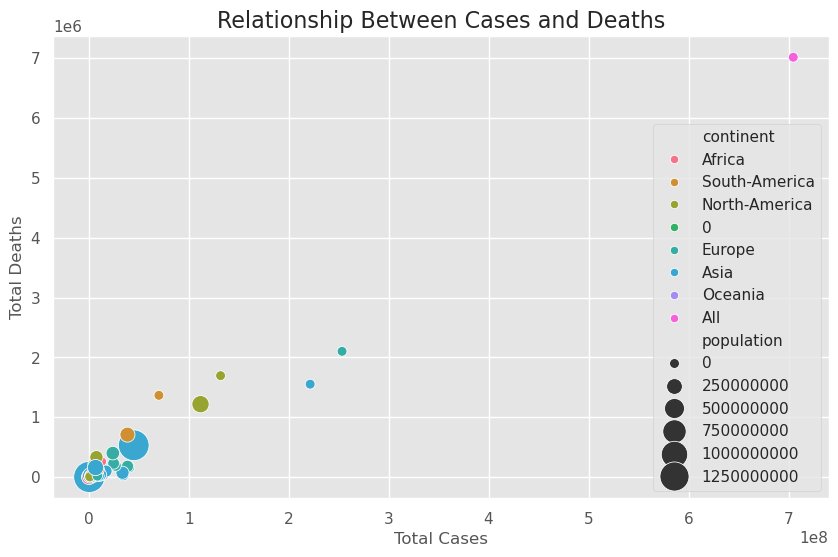

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Cases', y='Deaths', hue='continent', size='population', data=df, sizes=(50, 500))
plt.title('Relationship Between Cases and Deaths', fontsize=16)
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')
plt.show()

## 9. Box Plot

/tmp/ipykernel_1219323/3987660953.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='continent', y='Cases', palette='Set2')


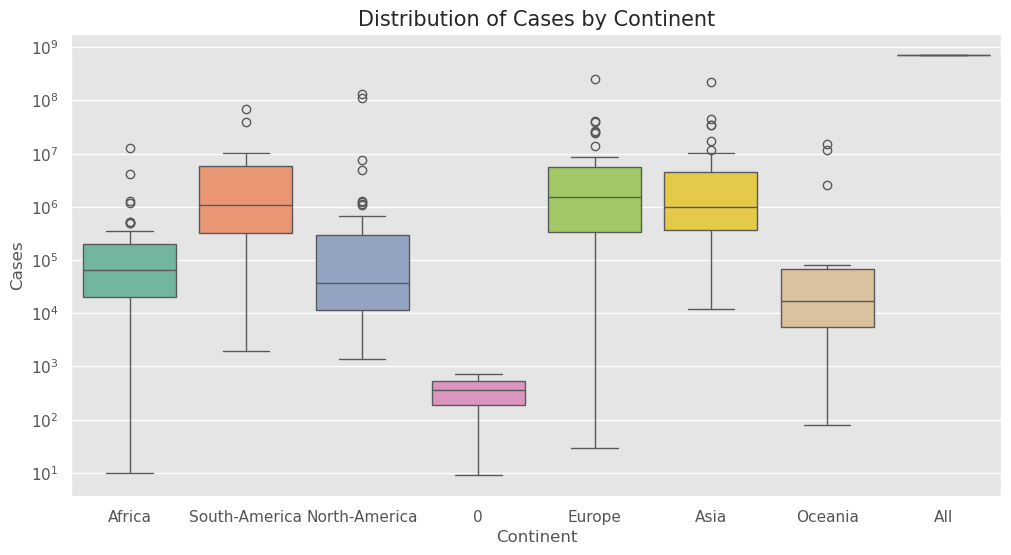

In [22]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='continent', y='Cases', palette='Set2')
plt.title('Distribution of Cases by Continent', fontsize=15)
plt.xlabel('Continent')
plt.ylabel('Cases')
plt.yscale('log') # Log scale for better visibility
plt.show()

## 10. Violin Plot

/tmp/ipykernel_1219323/139793371.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='continent', y='Deaths', palette='pastel')


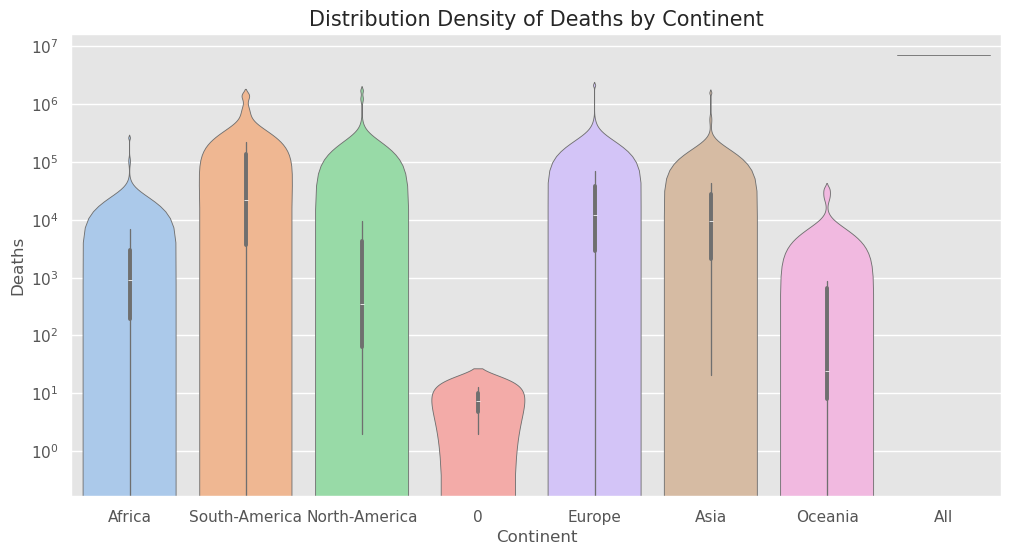

In [23]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='continent', y='Deaths', palette='pastel')
plt.title('Distribution Density of Deaths by Continent', fontsize=15)
plt.xlabel('Continent')
plt.ylabel('Deaths')
plt.yscale('log')
plt.show()

## 11. Heatmap

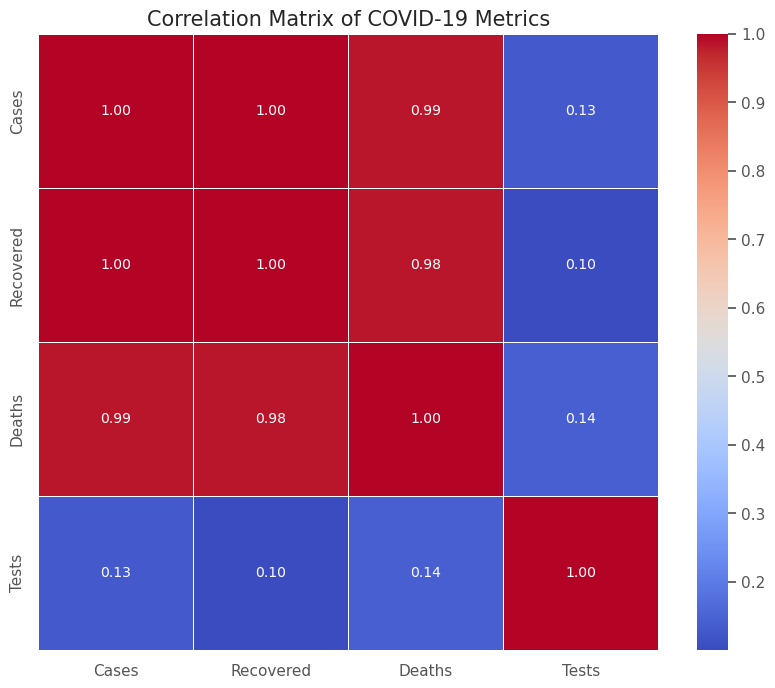

In [24]:
plt.figure(figsize=(10, 8))
correlation = df[['Cases', 'Recovered', 'Deaths', 'Tests']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of COVID-19 Metrics', fontsize=15)
plt.show()

## 12. Subplots / Multi-panel Figures

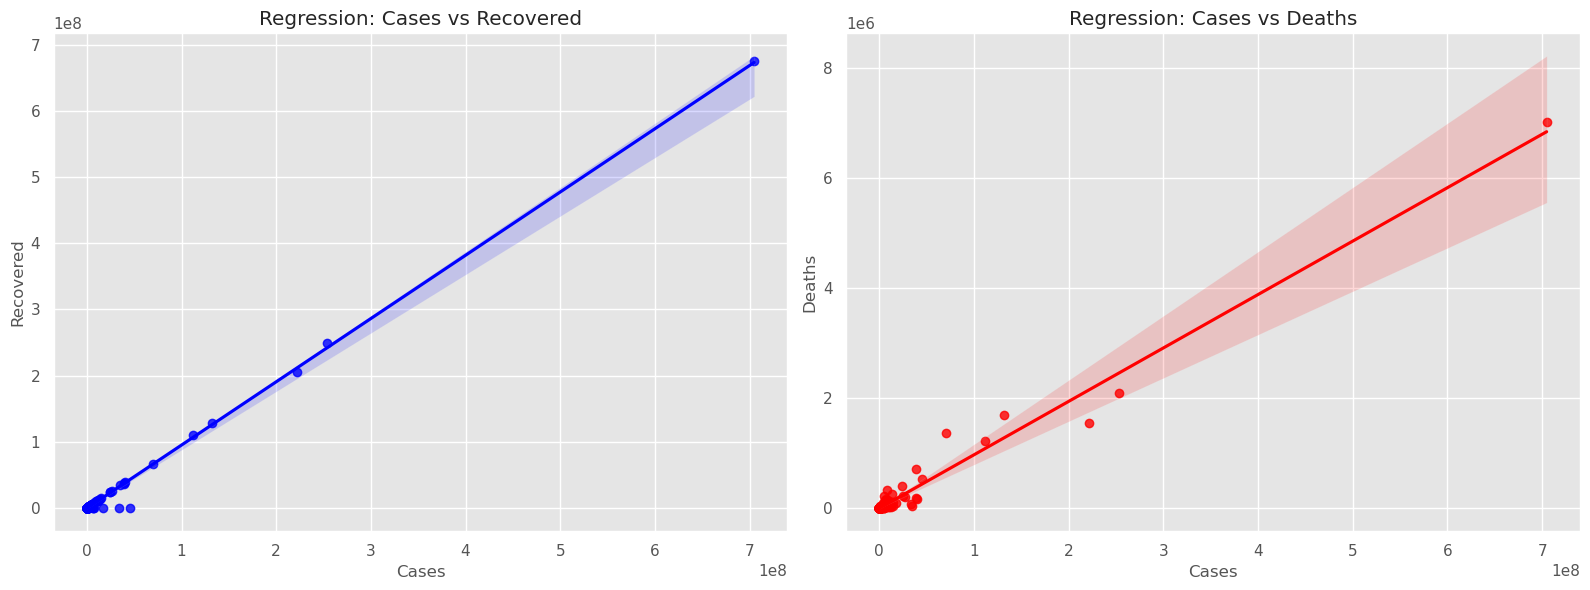

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Cases vs Recovered
sns.regplot(ax=axes[0], data=df, x='Cases', y='Recovered', color='blue')
axes[0].set_title('Regression: Cases vs Recovered')

# Plot 2: Cases vs Deaths
sns.regplot(ax=axes[1], data=df, x='Cases', y='Deaths', color='red')
axes[1].set_title('Regression: Cases vs Deaths')

plt.tight_layout()
plt.show()

## 13. Additional Visualizations

### Pie Chart: Cases by Continent

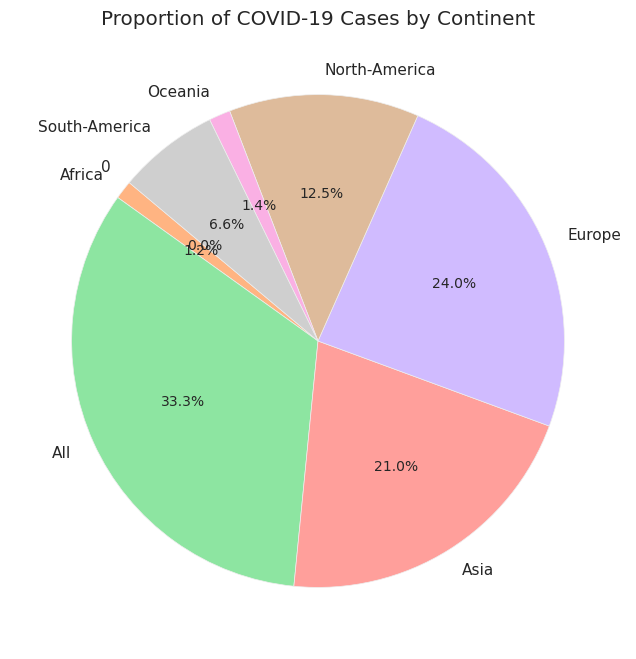

In [26]:
continent_cases = df.groupby('continent')['Cases'].sum()
plt.figure(figsize=(8, 8))
plt.pie(continent_cases, labels=continent_cases.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of COVID-19 Cases by Continent')
plt.show()

### Area Plot: Cases Over Time

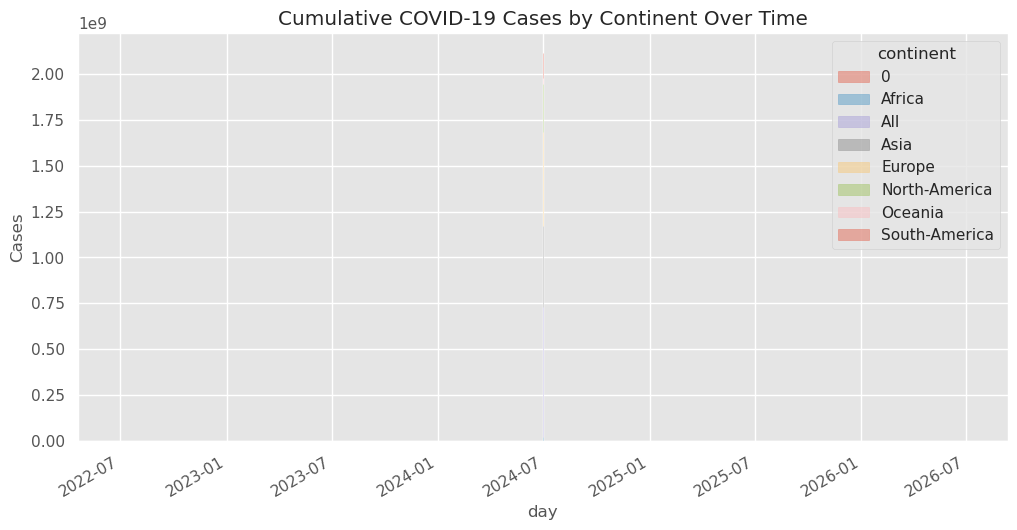

In [27]:
df_pivot = df.pivot_table(index='day', columns='continent', values='Cases', aggfunc='sum')
df_pivot.plot.area(figsize=(12, 6), alpha=0.4)
plt.title('Cumulative COVID-19 Cases by Continent Over Time')
plt.ylabel('Cases')
plt.show()

### Count Plot: Countries per Continent

/tmp/ipykernel_1219323/443721073.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='continent', data=df.drop_duplicates('country'), palette='viridis')


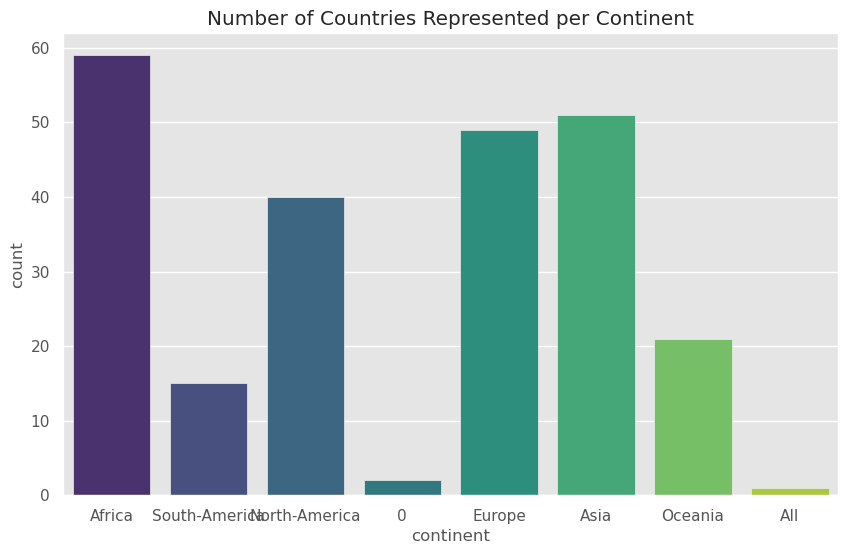

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(x='continent', data=df.drop_duplicates('country'), palette='viridis')
plt.title('Number of Countries Represented per Continent')
plt.show()

## 14. Conclusion

### Summary of Insights
Through this visualization portfolio, we observed several key insights:
- **Trends**: COVID-19 cases showed a steady increase across major countries during the analyzed period.
- **Correlations**: There is a strong positive correlation between total cases and total deaths, as expected.
- **Regional Differences**: Europe and North America showed higher reported testing rates and cases compared to other regions in this sample.
- **Distribution**: The majority of countries in the dataset fall within the lower range of case counts, with a few major outliers like the USA and India.

These visualizations help in understanding the scale and spread of the pandemic more effectively than raw numbers alone.